In [24]:
# Import your existing types and functions
from typing import Optional, Union
from dataclasses import dataclass
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

import pandas as pd
import torch
from torch import Tensor
from jaxtyping import Float, Bool

from js_embedding_vis import write_inlined_config

from muutils.collect_warnings import CollateWarnings
from muutils.dbg import dbg_auto, dbg_tensor


from spd.analysis.embed_vis import AnalysisConfig, coactivation_analysis, plot_embedding_label_grid
from spd.analysis.grouping import (
    CoactivationResults,
    CoactivationResultsGroup,
    get_coactivations,
)
from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.utils import get_device

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE = get_device()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = 'cuda'


In [ ]:
COACTIVATIONS = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    ),
    device=DEVICE,
)["group_0"]

dbg_auto(COACTIVATIONS);

[ <ipykernel>:18 ] COACTIVATIONS: <dict of len()=12, key_types={str}, val_types={Tensor, dict, float, int, list, ndarray}>
  co_occurrence_matrix: μ=2536.13 σ=8465.60 x̃=40.00 R=[0.00,100901.00] ℙ˪=|█▄▆▁ ▁▃| shape=(200,200) dtype=torch.float32 device=cuda:0 ∇✗
  marginal_counts: μ=25342.36 σ=38566.41 x̃=4717.00 R=[0.00,100901.00] ℙ=|█     ▂| shape=200 dtype=torch.float32 device=cuda:0 ∇✗
  module_slices:   <dict of len()=2, key_types={str}, val_types={slice}>
    layers.0.mlp_in: slice(0, 100, None)
    layers.0.mlp_out: slice(100, 200, None)
  modules: ['layers.0.mlp_in', 'layers.0.mlp_out']
  labels: shape=200 dtype=<U16
  group_masks: μ=0.02 σ=0.14 x̃=-0.00 R=[-0.05,1.00] ℙ˪=|█▅▅▅▅▅▅| shape=(1000,200) dtype=torch.float32 device=cuda:0 ∇✗
  active_mask: μ=0.05 σ=0.22 x̃=0.00 R=[0,1] ℙ˪=|█     ▆| shape=(1000,200) dtype=torch.bool device=cuda:0 ∇✗
  active_freq: μ=0.05 σ=0.08 x̃=0.01 R=[0.00,0.22] ℙ=|█    ▁▁| shape=200 dtype=torch.float32 device=cuda:0 ∇✗
  is_alive: μ=0.75 σ=0.43 x̃=1

In [14]:
def merge_cost_delta_all_pairs(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    ranks: Float[Tensor, "n_components"] | None = None,
    alpha: float = 1.0,
) -> Float[Tensor, "n_components n_components"]:
    """Compute change in MDL cost for merging all pairs of components

    $$
    F(P_{c1}, P_{c2}) = α||s_{c1}||_0 rank(P_{c2}) + α||s_{c2}||_0 rank(P_{c1})
                    - s_{c1} · s_{c2} (α rank(P_{c1}) + α rank(P_{c2}) + 1)
    $$

    # Parameters:
     - `co_occurrence_matrix : Float[Tensor, "n_components n_components"]`
        Matrix where entry (i,j) is number of samples where both components i and j are active
     - `marginal_counts : Float[Tensor, "n_components"]`
        Number of samples where each component is active (||s_c||_0)
     - `ranks : Float[Tensor, "n_components"] | None`
        Ranks of all components
        (defaults to `None`, which uses all ones)
     - `alpha : float`
        Regularization strength
        (defaults to `1.0`)

    # Returns:
     - `Float[Tensor, "n_components n_components"]`
        Cost delta matrix where entry (i,j) is cost change for merging components i and j
        (negative means merging reduces cost)
    """
    n_components = marginal_counts.shape[0]
    
    if ranks is None:
        ranks = torch.ones(n_components, device=marginal_counts.device)
    
    # Expand to broadcast: marginal_counts[i] for all pairs (i,j)
    l0_s_c1 = marginal_counts.unsqueeze(1)  # [n_components, 1]
    l0_s_c2 = marginal_counts.unsqueeze(0)  # [1, n_components]
    
    # Expand ranks similarly
    rank_c1 = ranks.unsqueeze(1)  # [n_components, 1] 
    rank_c2 = ranks.unsqueeze(0)  # [1, n_components]
    
    cost_delta = (
        alpha * l0_s_c1 * rank_c2 +
        alpha * l0_s_c2 * rank_c1 -
        co_occurrence_matrix * (alpha * rank_c1 + alpha * rank_c2 + 1)
    )
    
    return cost_delta

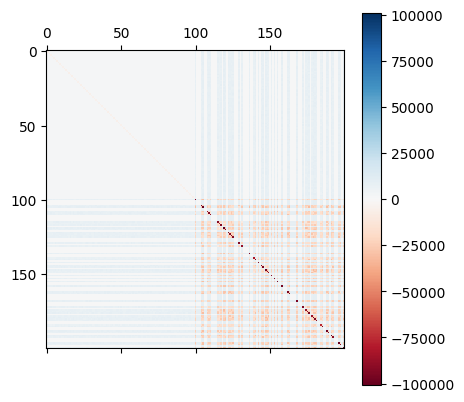

In [20]:
merge_costs = merge_cost_delta_all_pairs(
	COACTIVATIONS["co_occurrence_matrix"],
	COACTIVATIONS["marginal_counts"],
	alpha=0.1,
)
import matplotlib.pyplot as plt
vlim = merge_costs.abs().max().item()
plt.matshow(merge_costs.cpu(), cmap="RdBu", vmin=-vlim, vmax=vlim)
plt.colorbar()

the above actually makes sense. the last 100 are the superimposed components which we expect to merge into one super-component.

In [ ]:



@dataclass
class MergeNode:
    """Node in the merge tree"""
    id: int
    children: Optional[tuple['MergeNode', 'MergeNode']] = None
    original_idx: Optional[int] = None  # For leaf nodes
    rank: int = 1
    
    def is_leaf(self) -> bool:
        return self.children is None


def merge_components_iterative(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    ranks: Optional[Float[Tensor, "n_components"]] = None,
    alpha: float = 1.0,
    max_iterations: int = 10,
    randomness: float = 0.0,
    seed: Optional[int] = None,
) -> dict[str, Union[list, Tensor, bool]]:
    """Iteratively merge components using MDL cost
    
    # Parameters:
     - `co_occurrence_matrix : Float[Tensor, "n_components n_components"]`
        Matrix where entry (i,j) is number of samples where both components i and j are active
     - `marginal_counts : Float[Tensor, "n_components"]`
        Number of samples where each component is active
     - `ranks : Optional[Float[Tensor, "n_components"]]`
        Initial ranks of all components
        (defaults to `None`, which uses all ones)
     - `alpha : float`
        Regularization strength
        (defaults to `1.0`)
     - `max_iterations : int`
        Maximum number of merge operations
        (defaults to `10`)
     - `randomness : float`
        Amount of randomness in merge selection. 0.0 = pure greedy, 1.0 = uniform random
        (defaults to `0.0`)
     - `seed : Optional[int]`
        Random seed for reproducibility
        (defaults to `None`)
    
    # Returns:
     - `dict[str, Union[list, Tensor, bool]]`
        Results containing merge history, final tree, and updated data structures
    """
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
    
    n_components: int = marginal_counts.shape[0]
    device = marginal_counts.device
    
    if ranks is None:
        ranks = torch.ones(n_components, device=device)
    
    # Initialize merge tree nodes for original components
    nodes: list[MergeNode] = [
        MergeNode(id=i, original_idx=i, rank=int(ranks[i].item()))
        for i in range(n_components)
    ]
    
    # Track merge history
    merge_history: list[dict[str, Union[int, float, tuple[int, int]]]] = []
    next_node_id: int = n_components
    
    # Working copies - start with original data
    current_co_occurrence: Float[Tensor, "active_components	 active_components"] = co_occurrence_matrix.clone()
    current_marginal_counts: Float[Tensor, "active_components"] = marginal_counts.clone()
    current_ranks: Float[Tensor, "active_components"] = ranks.clone()
    
    # Map from current matrix indices to original component indices
    active_to_original: list[int] = list(range(n_components))
    
    for iteration in range(max_iterations):
        n_active: int = current_co_occurrence.shape[0]
        
        if n_active < 2:
            print(f"Stopping: only {n_active} active components remaining")
            break
        
        # Compute cost deltas for all active pairs
        cost_matrix: Float[Tensor, "active_components active_components"] = merge_cost_delta_all_pairs(
            current_co_occurrence, current_marginal_counts, current_ranks, alpha
        )
        
        # Mask diagonal to prevent self-merges
        cost_matrix.fill_diagonal_(float('inf'))
        
        # Select merge pair with configurable randomness
        valid_mask: Bool[Tensor, "active_components active_components"] = ~torch.isinf(cost_matrix)
        if not valid_mask.any():
            print("No valid merges remaining")
            break
            
        if randomness == 0.0:
            # Pure greedy: take best cost
            best_flat_idx: Tensor = cost_matrix.argmin()
        else:
            # Add randomness: sample from top candidates
            flat_costs: Float[Tensor, "active_components_squared"] = cost_matrix.flatten()
            sorted_indices: Tensor = torch.argsort(flat_costs)
            valid_sorted: Tensor = sorted_indices[~torch.isinf(flat_costs[sorted_indices])]
            
            if len(valid_sorted) == 0:
                break
                
            # Choose from top candidates based on randomness
            n_candidates: int = max(1, int(len(valid_sorted) * (1 - randomness)))
            candidate_idx: int = random.randint(0, n_candidates - 1)
            best_flat_idx = valid_sorted[candidate_idx]
        
        # Convert flat index to 2D coordinates
        i_active, j_active = torch.unravel_index(best_flat_idx, cost_matrix.shape)
        i_active, j_active = i_active.item(), j_active.item()
        
        if i_active > j_active:  # Ensure i < j for consistency
            i_active, j_active = j_active, i_active
            
        merge_cost: float = cost_matrix[i_active, j_active].item()
        
        # Map back to original indices for recording
        i_orig: int = active_to_original[i_active]
        j_orig: int = active_to_original[j_active]
        
        # Record merge
        merge_info: dict[str, Union[int, float, tuple[int, int]]] = {
            'iteration': iteration,
            'components': (i_orig, j_orig),
            'cost_delta': merge_cost,
            'ranks': (current_ranks[i_active].item(), current_ranks[j_active].item()),
            'marginal_counts': (current_marginal_counts[i_active].item(), current_marginal_counts[j_active].item()),
            'co_occurrence': current_co_occurrence[i_active, j_active].item(),
        }
        merge_history.append(merge_info)
        
        print(f"Iteration {iteration}: Merging components {i_orig} and {j_orig} "
              f"(cost_delta={merge_cost:.3f}, ranks={current_ranks[i_active].item()}+{current_ranks[j_active].item()})")
        
        # Create new merged node
        merged_node: MergeNode = MergeNode(
            id=next_node_id,
            children=(nodes[i_orig], nodes[j_orig]),
            rank=int(current_ranks[i_active].item() + current_ranks[j_active].item())
        )
        nodes.append(merged_node)
        next_node_id += 1
        
        # Compute merged component properties
        new_marginal_count: Tensor = torch.max(current_marginal_counts[i_active], current_marginal_counts[j_active])
        new_rank: Tensor = current_ranks[i_active] + current_ranks[j_active]
        
        # Compute new co-occurrence row/col: max pooling with existing components
        new_co_occurrence_row: Float[Tensor, "active_components"] = torch.max(
            current_co_occurrence[i_active, :], current_co_occurrence[j_active, :]
        )
        
        # Create smaller matrices by removing the two merged components and adding the new one
        keep_mask: Bool[Tensor, "active_components"] = torch.ones(n_active, dtype=torch.bool, device=device)
        keep_mask[i_active] = False
        keep_mask[j_active] = False
        
        # Update co-occurrence matrix
        kept_co_occurrence: Float[Tensor, "kept_components kept_components"] = current_co_occurrence[keep_mask][:, keep_mask]
        kept_new_row: Float[Tensor, "kept_components"] = new_co_occurrence_row[keep_mask]
        
        # Build new smaller matrix
        n_kept: int = kept_co_occurrence.shape[0]
        new_size: int = n_kept + 1
        
        new_co_occurrence_matrix: Float[Tensor, "new_size new_size"] = torch.zeros(new_size, new_size, device=device)
        new_co_occurrence_matrix[:n_kept, :n_kept] = kept_co_occurrence
        new_co_occurrence_matrix[n_kept, :n_kept] = kept_new_row
        new_co_occurrence_matrix[:n_kept, n_kept] = kept_new_row
        new_co_occurrence_matrix[n_kept, n_kept] = new_marginal_count
        
        # Update other vectors
        kept_marginal_counts: Float[Tensor, "kept_components"] = current_marginal_counts[keep_mask]
        new_marginal_counts_vec: Float[Tensor, "new_size"] = torch.cat([kept_marginal_counts, new_marginal_count.unsqueeze(0)])
        
        kept_ranks: Float[Tensor, "kept_components"] = current_ranks[keep_mask]
        new_ranks_vec: Float[Tensor, "new_size"] = torch.cat([kept_ranks, new_rank.unsqueeze(0)])
        
        # Update mapping from active indices to original/node indices
        kept_original: list[int] = [active_to_original[k] for k in range(n_active) if keep_mask[k]]
        new_active_to_original: list[int] = kept_original + [merged_node.id]
        
        # Update working copies
        current_co_occurrence = new_co_occurrence_matrix
        current_marginal_counts = new_marginal_counts_vec
        current_ranks = new_ranks_vec
        active_to_original = new_active_to_original
    
    # Find final active nodes
    final_nodes: list[MergeNode] = []
    for active_idx in active_to_original:
        if active_idx < n_components:
            final_nodes.append(nodes[active_idx])
        else:
            final_nodes.append(nodes[active_idx])
    
    results: dict[str, Union[list, Tensor, bool]] = {
        'merge_history': merge_history,
        'final_nodes': final_nodes,
        'final_co_occurrence_matrix': current_co_occurrence,
        'final_marginal_counts': current_marginal_counts,
        'final_ranks': current_ranks,
        'all_nodes': nodes,
        'active_to_original': active_to_original,
    }
    
    return results



In [28]:
# Run merging
results: dict[str, Union[list, Tensor, bool]] = merge_components_iterative(
    COACTIVATIONS["co_occurrence_matrix"], 
    COACTIVATIONS["marginal_counts"],
    max_iterations=1000,
    randomness=0.0,  # Pure greedy
    alpha=0.1,
)


Iteration 0: Merging components 147 and 179 (cost_delta=-32678.201, ranks=1.0+1.0)
Iteration 1: Merging components 148 and 180 (cost_delta=-31524.301, ranks=1.0+1.0)
Iteration 2: Merging components 105 and 176 (cost_delta=-31504.004, ranks=1.0+1.0)
Iteration 3: Merging components 119 and 174 (cost_delta=-31001.301, ranks=1.0+1.0)
Iteration 4: Merging components 155 and 191 (cost_delta=-30397.102, ranks=1.0+1.0)
Iteration 5: Merging components 149 and 178 (cost_delta=-29814.100, ranks=1.0+1.0)
Iteration 6: Merging components 158 and 163 (cost_delta=-29405.902, ranks=1.0+1.0)
Iteration 7: Merging components 125 and 196 (cost_delta=-29256.801, ranks=1.0+1.0)
Iteration 8: Merging components 131 and 145 (cost_delta=-29141.004, ranks=1.0+1.0)
Iteration 9: Merging components 123 and 162 (cost_delta=-28784.801, ranks=1.0+1.0)
Iteration 10: Merging components 122 and 144 (cost_delta=-28239.602, ranks=1.0+1.0)
Iteration 11: Merging components 104 and 189 (cost_delta=-27609.801, ranks=1.0+1.0)
It